In [1]:
# Standard scientific libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize

# Set plotting style for better visualization
plt.style.use("seaborn-v0_8")

Viral Load Data:
   time  value
0     0  2.652
1     8  2.951
2    24  4.120
3    48  4.256
4    72  3.128 

Interferon Data:
   time   value
0     0   2.188
1     8   7.098
2    24  12.054
3    48  12.411
4    72  11.563


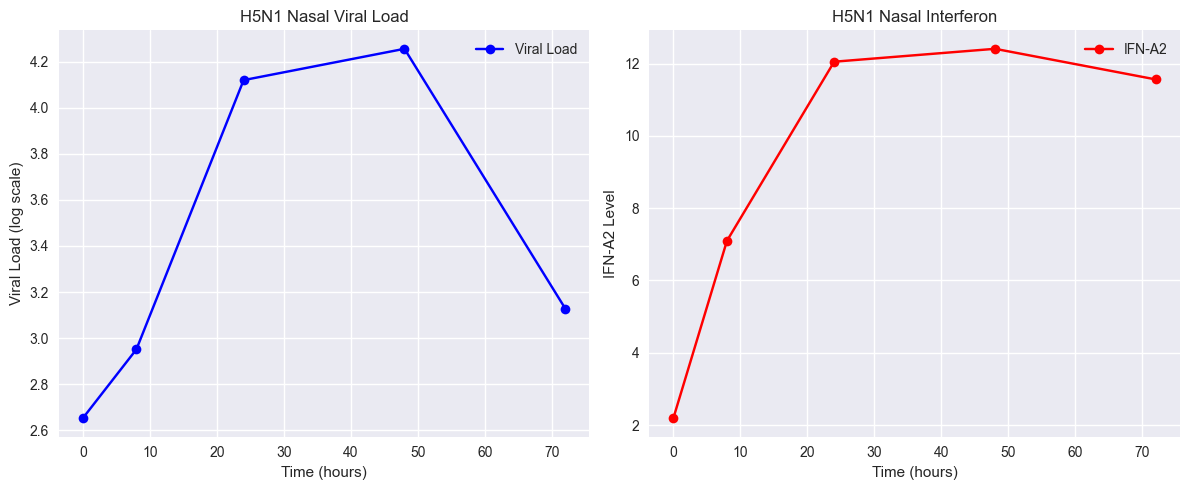

In [2]:
vl_path = "/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/data/nasal_data/h5n1(2005)/nasal_h5n1_2005_vl.txt"
t1_path = "/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/data/nasal_data/h5n1(2005)/nasal_h5n1_2005_t1.txt"

# Load the viral load data
vl_data = pd.read_csv(vl_path)
print("Viral Load Data:")
print(vl_data, "\n")

# Load the interferon data
t1_data = pd.read_csv(t1_path)
print("Interferon Data:")
print(t1_data)

# Let's also create a simple plot to visualize our data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot viral load data
ax1.plot(vl_data['time'], vl_data['value'], 'o-', color='blue', label='Viral Load')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Viral Load (log scale)')
ax1.set_title('H5N1 Nasal Viral Load')
ax1.legend()

# Plot interferon data
ax2.plot(t1_data['time'], t1_data['value'], 'o-', color='red', label='IFN-A2')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('IFN-A2 Level')
ax2.set_title('H5N1 Nasal Interferon')
ax2.legend()

plt.tight_layout()
plt.savefig('nasal_h5n1_2005.png')
plt.show()

In [3]:
def Model(y, t, beta, gamma, rho, delta, p, c, alpha):
    """
    Extended model with resistant cell class
    
    Parameters:
    y: list of variables [T, R, I, V, F]
    t: time points
    beta: infection rate
    gamma: rate of conversion to resistant state
    rho: rate of return from resistant state
    delta: death rate of infected cells
    p: virus production rate
    c: virus clearance rate
    alpha: interferon clearance rate
    """
    T, R, I, V, F = y
    
    # System of ODEs
    dTdt = -beta * T * V - gamma * T * F    # Target cells
    dRdt = gamma * T * F - rho * R          # Resistant cells
    dIdt = beta * T * V - delta * I         # Infected cells
    dVdt = p * I - c * V                    # Virus
    dFdt = I - alpha * F                    # Interferon
    
    return [dTdt, dRdt, dIdt, dVdt, dFdt]

# Initial conditions
T0 = 1.0     # Initial target cells (normalized)
R0 = 0.0     # Initial resistant cells
I0 = 0.0     # Initial infected cells
V0 = vl_data['value'].iloc[0]    # Initial virus from data
F0 = t1_data['value'].iloc[0]    # Initial interferon from data
y0 = [T0, R0, I0, V0, F0]

print("Initial conditions:")
for var, val in zip(['T0', 'R0', 'I0', 'V0', 'F0'], y0):
    print(f"{var} = {val}")

Initial conditions:
T0 = 1.0
R0 = 0.0
I0 = 0.0
V0 = 2.652
F0 = 2.188


In [4]:
# Create two sets of time points:
# 1. Data time points for comparison
data_times = np.array([0, 8, 24, 48, 72])

# 2. Integration time points (finer mesh for solving ODEs)
t = np.linspace(0, 72, 100)

def optimize(params):
    """
    Objective function to minimize.
    Uses relative error at actual data time points.
    """
    beta, gamma, rho, delta, p, c, alpha = params
    
    try:
        # Solve ODE system
        solution = odeint(Model, y0, t, args=(beta, gamma, rho, delta, p, c, alpha))
        _, _, _, V, F = solution.T
        
        # Get model predictions at data time points
        # Find indices in t that correspond to data_times
        indices = [np.where(np.isclose(t, time))[0][0] for time in data_times]
        global V_model, F_model
        V_model = V[indices]
        F_model = F[indices]
        
        # Calculate relative SSR
        vl_ssr = np.sum((((np.maximum(V_model, 0)) - vl_data['value'])/vl_data['value'])**2)
        ifn_ssr = np.sum(((F_model - t1_data['value'])/t1_data['value'])**2)
        
        total_ssr = vl_ssr + ifn_ssr
        
        print(f"Parameters: {params} | SSR: {total_ssr}")
        return total_ssr
    except:
        return 1e12  # Large number if integration fails

print("Data time points:", data_times)
print("\nNumber of integration points:", len(t))
print("Integration time range:", t[0], "to", t[-1])

Data time points: [ 0  8 24 48 72]

Number of integration points: 100
Integration time range: 0.0 to 72.0


In [5]:
# guess =  [5, 2, .1, 0.3, 0.2, 1]
# guess =  [8.343820383462457, 0.14227915640397182, 24.999803292031743, 1.0000000000000006e-06, 9.943491537961386, 99.99999705549871]
# guess =  [14.99962824221421, 0.14325122860273118, 25.0, 1.0041844271121745e-06, 9.999991155086164, 99.99999433433749]
# guess =  [18157.22935023227, 0.2675500608913878, 3188.941873829718, -0.0044186634094281335, 121.52095549498222, 102099.2414743583]
# guess =  [12.462564035211152, 0.26890545724797177, 24.4609077003097, 0.004419028064124291, 16.60630496689475, 10.03528493777]
# guess =  [33.7023621186502087, 0.11169188982976419, 6.500142109750015, 0.002728635855545944, 12.962759191783146, 24.97498620729047]
# guess =  [np.float64(9.73022706705976), np.float64(0.14705740036139425), np.float64(10.482899086173001), np.float64(0.0001001617005785607), np.float64(19.586219970862402), np.float64(49.99931161312256)]
# guess =  [np.float64(95.02768120275016), np.float64(0.03851942379976944), np.float64(99.9956199846182), np.float64(0.0014071999313988474), np.float64(0.0001000000000000026), np.float64(12.033396988200224)]
# guess =  [np.float64(99.95319080865168), np.float64(0.03677078825573739), np.float64(2.031858793925287), np.float64(0.00010000000000000005), np.float64(0.00010000000000000015), np.float64(0.3836716139186588)]
guess = [0.1, 0.1, 0.1, 0.1, 10.0, 0.1, 0.1]
# guess =  [np.float64(0.2616240437987206), np.float64(0.007741308981467715), np.float64(0.0005670517761060686), np.float64(0.011253218678742093), np.float64(0.2406675792688321), np.float64(0.04054524347857762), np.float64(0.0481008268088121)]
# guess =  [np.float64(1.41933957419305695), np.float64(0.8507848651301964), np.float64(0.08937375770061394), np.float64(1e-04), np.float64(9.30114341865344), np.float64(1.501395425002275), np.float64(0.05334190771421912)]
# guess =  [np.float64(0.10157896959292984), np.float64(4.453330288803492), np.float64(3.9429722115291366), np.float64(0.18387418320919743), np.float64(5.08310427812775), np.float64(0.74103490716405128), np.float64(8.72755868811683e-06)]
guess =  [np.float64(0.01763976045131576), np.float64(0.10157608746550417), np.float64(0.9300489715686392), np.float64(0.003251932257542672), np.float64(13.938215959496123), np.float64(0.4135652152476109), np.float64(0.02074573283565041)]


In [6]:
bounds = [
    (1e-6, 10.0),   # beta
    (1e-6, 10.0),   # gamma
    (1e-6, 10.0),   # rho 
    (1e-6, 10.0),   # delta
    (1e-1, 1e7), #p
    (1e-6, 10.0),   # c
    (1e-6, 100.0)    # alpha
]

print("Initial parameter guesses:")
for param, value in zip(['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha'], guess):
    print(f"{param}: {value}")

Initial parameter guesses:
beta: 0.01763976045131576
gamma: 0.10157608746550417
rho: 0.9300489715686392
delta: 0.003251932257542672
p: 13.938215959496123
c: 0.4135652152476109
alpha: 0.02074573283565041


In [7]:
# Perform optimization
result = minimize(optimize, guess, method ='Nelder-Mead', bounds=bounds)

# Extract optimized parameters
beta_fit, gamma_fit, rho_fit, delta_fit, p_fit, c_fit, alpha_fit = result.x

# Generate solution with optimized parameters
solution_fit = odeint(Model, y0, t, args=(beta_fit, gamma_fit, rho_fit, delta_fit, p_fit, c_fit, alpha_fit))
T_fit, R_fit, I_fit, V_fit, F_fit = solution_fit.T

# Print optimization results
print("Optimization successful:", result.success)
print("Number of iterations:", result.nit)
print("\nOptimized parameters:")
param_names = ['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha']
for name, value in zip(param_names, result.x):
    print(f"{name}: {value:.6f}")

print("guess = ", [i for i in result.x])

Parameters: [1.76397605e-02 1.01576087e-01 9.30048972e-01 3.25193226e-03
 1.39382160e+01 4.13565215e-01 2.07457328e-02] | SSR: 1.7829502847859893
Parameters: [1.85217485e-02 1.01576087e-01 9.30048972e-01 3.25193226e-03
 1.39382160e+01 4.13565215e-01 2.07457328e-02] | SSR: 1.8807449491023167
Parameters: [1.76397605e-02 1.06654892e-01 9.30048972e-01 3.25193226e-03
 1.39382160e+01 4.13565215e-01 2.07457328e-02] | SSR: 1.7438751430026573
Parameters: [1.76397605e-02 1.01576087e-01 9.76551420e-01 3.25193226e-03
 1.39382160e+01 4.13565215e-01 2.07457328e-02] | SSR: 1.7829503064010923
Parameters: [1.76397605e-02 1.01576087e-01 9.30048972e-01 3.41452887e-03
 1.39382160e+01 4.13565215e-01 2.07457328e-02] | SSR: 1.7738676990347366
Parameters: [1.76397605e-02 1.01576087e-01 9.30048972e-01 3.25193226e-03
 1.46351268e+01 4.13565215e-01 2.07457328e-02] | SSR: 1.9738483163623122
Parameters: [1.76397605e-02 1.01576087e-01 9.30048972e-01 3.25193226e-03
 1.39382160e+01 4.34243476e-01 2.07457328e-02] | SS


Final SSR: 0.027272


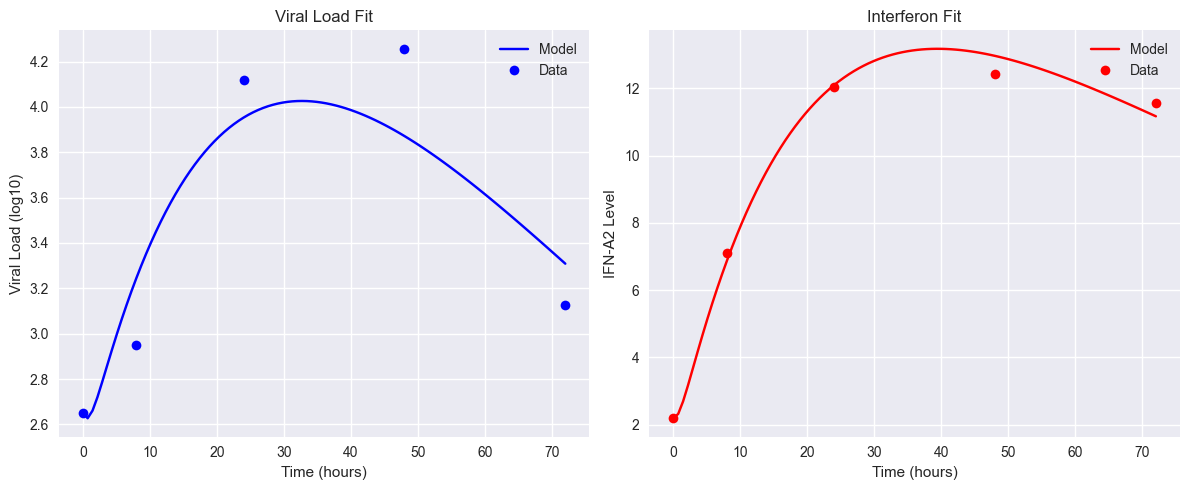

In [8]:
# Calculate final SSR
final_ssr = result.fun
print(f"\nFinal SSR: {final_ssr:.6f}")

# Plot results
plt.figure(figsize=(12, 5))

# Plot viral load
plt.subplot(121)
plt.plot(t, (V_fit), 'b-', label='Model')
plt.plot(vl_data['time'], vl_data['value'], 'bo', label='Data')
plt.xlabel('Time (hours)')
plt.ylabel('Viral Load (log10)')
plt.legend()
plt.title('Viral Load Fit')

# Plot interferon
plt.subplot(122)
plt.plot(t, F_fit, 'r-', label='Model')
plt.plot(t1_data['time'], t1_data['value'], 'ro', label='Data')
plt.xlabel('Time (hours)')
plt.ylabel('IFN-A2 Level')
plt.legend()
plt.title('Interferon Fit')

plt.tight_layout()
plt.savefig("nasal_fit_h5n1_2005.png")
plt.show()

In [9]:
# %% Bootstrap Analysis
import os

# Create output directory
strain = "h5n1(2005)"  # Change for each file
location = "nasal"     # Change for each file
output_dir = f"/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/code/model3/{strain}/{location}/bootstrap_results"
os.makedirs(output_dir, exist_ok=True)
output_prefix = f"{output_dir}/{strain}_{location}"

# Calculate residuals between data and best-fit model
# Find indices for data_times in t
indices = [np.where(np.isclose(t, time))[0][0] for time in data_times]
V_best = V_fit[indices]
F_best = F_fit[indices]

# Calculate residuals (use for bootstrapping)
residuals_viral = vl_data['value'] - V_best
residuals_ifn = t1_data['value'] - F_best

# Use best-fit parameters from previous optimization
best_params = [beta_fit, gamma_fit, rho_fit, delta_fit, p_fit, c_fit, alpha_fit]

# Define bootstrap optimization function that uses relative error
def optimize_bootstrap(params, new_viral_data, new_ifn_data):
    """
    Objective function for bootstrap optimization.
    Uses relative error just like the original optimize function.
    """
    beta, gamma, rho, delta, p, c, alpha = params
    
    try:
        # Solve ODE system
        solution = odeint(Model, y0, t, args=(beta, gamma, rho, delta, p, c, alpha))
        _, _, _, V, F = solution.T
        
        # Get model predictions at data time points
        indices = [np.where(np.isclose(t, time))[0][0] for time in data_times]
        V_pred = V[indices]
        F_pred = F[indices]
        
        # Calculate relative SSR (same method as in original optimize function)
        vl_ssr = np.sum((((np.maximum(V_pred, 0)) - new_viral_data)/new_viral_data)**2)
        ifn_ssr = np.sum(((F_pred - new_ifn_data)/new_ifn_data)**2)
        
        total_ssr = vl_ssr + ifn_ssr
        return total_ssr
    except:
        return 1e12  # Large number if integration fails

# Number of bootstrap samples
n_bootstrap = 1000

# Initialize arrays for bootstrap results
bootstrap_params = []
bootstrap_ssr = []

print(f"Starting bootstrap analysis with {n_bootstrap} samples")
print(f"Using best-fit parameters: {best_params}")

# Run bootstrap
for i in range(n_bootstrap):
    # Generate new datasets by resampling residuals
    new_viral_data = V_best + np.random.choice(residuals_viral, size=len(residuals_viral), replace=True)
    new_ifn_data = F_best + np.random.choice(residuals_ifn, size=len(residuals_ifn), replace=True)
    
    # Ensure non-negative values
    new_viral_data = np.maximum(new_viral_data, 1e-6)  # Using small positive number instead of zero for relative error
    new_ifn_data = np.maximum(new_ifn_data, 1e-6)
    
    # Optimize with new dataset
    result_bootstrap = minimize(
        optimize_bootstrap, 
        best_params, 
        args=(new_viral_data, new_ifn_data), 
        method='Nelder-Mead',  
        bounds=bounds
    )
    
    bootstrap_params.append(result_bootstrap.x)
    bootstrap_ssr.append(result_bootstrap.fun)
    
    if (i+1) % 10 == 0 or i == 0:
        print(f"Processing bootstrap sample {i+1}/{n_bootstrap}")
        print(f"Sample {i+1} parameters: {result_bootstrap.x}")
        print(f"Sample {i+1} SSR: {result_bootstrap.fun}")

# Save bootstrap parameters and SSR to text files
np.savetxt(f"{output_prefix}_params.txt", np.array(bootstrap_params), delimiter=",")
np.savetxt(f"{output_prefix}_ssr.txt", np.array(bootstrap_ssr), delimiter=",")

# Calculate and print statistics
print(f"\nBootstrap Statistics:")
print(f"Mean SSR: {np.mean(bootstrap_ssr)}")
print(f"Median SSR: {np.median(bootstrap_ssr)}")
print(f"Standard Deviation of SSR: {np.std(bootstrap_ssr)}")

# Calculate parameter statistics
param_names = ['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha']
param_stats = {}

# Create a results summary file
with open(f"{output_prefix}_summary.txt", "w") as f:
    f.write(f"Bootstrap Results Summary for {strain} {location}\n")
    f.write(f"Number of bootstrap samples: {n_bootstrap}\n\n")
    f.write(f"SSR Statistics:\n")
    f.write(f"Mean: {np.mean(bootstrap_ssr):.6f}\n")
    f.write(f"Median: {np.median(bootstrap_ssr):.6f}\n")
    f.write(f"Std Dev: {np.std(bootstrap_ssr):.6f}\n\n")
    
    f.write(f"Parameter Statistics:\n")
    for i, name in enumerate(param_names):
        param_values = np.array(bootstrap_params)[:, i]
        mean_val = np.mean(param_values)
        median_val = np.median(param_values)
        ci_low = np.percentile(param_values, 2.5)
        ci_high = np.percentile(param_values, 97.5)
        
        param_stats[name] = {
            'mean': mean_val,
            'median': median_val,
            'ci_low': ci_low,
            'ci_high': ci_high
        }
        
        f.write(f"{name}:\n")
        f.write(f"  Mean: {mean_val:.6f}\n")
        f.write(f"  Median: {median_val:.6f}\n")
        f.write(f"  95% CI: [{ci_low:.6f}, {ci_high:.6f}]\n\n")

# Plot parameter distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, name in enumerate(param_names):
    if i < len(axes):
        ax = axes[i]
        param_values = np.array(bootstrap_params)[:, i]
        n_bins = min(20, max(10, len(param_values)//50))  # Adaptive bin count 
        ax.hist(param_values, bins=n_bins, alpha=0.7, color='skyblue')
        ax.axvline(best_params[i], color='r', linestyle='--', label='Best fit')
        ax.axvline(param_stats[name]['mean'], color='g', linestyle='-', label='Bootstrap mean')
        ax.axvline(param_stats[name]['ci_low'], color='k', linestyle=':', label='95% CI')
        ax.axvline(param_stats[name]['ci_high'], color='k', linestyle=':')
        ax.set_title(f'{name}')
        ax.set_xlabel('Parameter value')
        ax.set_ylabel('Frequency')
        if i == 0:  # Only add legend to first plot
            ax.legend()

# Remove empty subplots if any
for i in range(len(param_names), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(f"{output_prefix}_param_distributions.png", dpi=300)
plt.close()

print(f"Bootstrap analysis complete. Results saved to {output_dir}")

Starting bootstrap analysis with 1000 samples
Using best-fit parameters: [np.float64(0.3742799215184395), np.float64(0.03132965454082742), np.float64(7.009995416349138), np.float64(0.011034191875474136), np.float64(0.23318502945709246), np.float64(0.03782722801196571), np.float64(0.0460278613201503)]
Processing bootstrap sample 1/1000
Sample 1 parameters: [9.99996891e+00 1.71285487e+00 5.27917275e-01 8.60632078e-03
 2.03830266e-01 3.34596755e-02 4.83306776e-02]
Sample 1 SSR: 0.011157983063036728
Processing bootstrap sample 10/1000
Sample 10 parameters: [2.92576048e-01 1.00035371e-06 9.78973542e+00 1.15512347e-02
 1.50666439e-01 2.44681886e-02 4.76301545e-02]
Sample 10 SSR: 0.12371130456280277
Processing bootstrap sample 20/1000
Sample 20 parameters: [2.77937695e-01 1.00009039e-06 8.14719776e+00 8.45199443e-03
 1.89057033e-01 3.78227992e-02 5.44560320e-02]
Sample 20 SSR: 0.13314843767127077
Processing bootstrap sample 30/1000
Sample 30 parameters: [4.01770098e-01 1.00001301e-06 3.599826